In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import clone

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

In [9]:
pd.set_option('display.max_columns', None)
X_train = pd.read_csv('data/train075_apache_only.csv')
y_train = pd.read_csv('data/Ytrain075.csv').squeeze()
X_test = pd.read_csv('data/test_apache_only.csv').squeeze()
y_test = pd.read_csv('data/y_test.csv')
X_train.head(5)

,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_diagnosis,age,pre_icu_los_days,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis
0,2.9,0.0,0.0,0.7,22.0,1.04,0.5,4.0,6.0,0.0,5.0,86.0,120.0,21.8,0.0,53.0,40.0,103.0,7.36,35.0,137.0,36.3,2599.5168,0.0,13.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.040283,74.0,0.259722,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.9,0.0,0.0,0.7,12.0,0.66,0.5,4.0,6.0,0.0,5.0,115.0,105.0,29.0,0.0,57.0,40.0,103.0,7.36,60.0,137.0,36.4,1387.2384,0.0,6.3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.041844,66.0,0.052778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.4,0.0,0.0,0.8,26.0,3.03,0.5,4.0,6.0,0.0,5.0,284.0,60.0,38.5,0.0,157.0,40.0,103.0,7.36,38.0,140.0,36.7,1387.2384,0.0,11.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.034791,64.0,0.355556,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,2.9,0.0,0.0,0.7,19.0,0.99,0.5,4.0,6.0,0.0,5.0,213.0,46.0,33.2,0.0,75.0,40.0,103.0,7.36,8.0,138.0,36.6,2015.1072,0.0,10.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.097194,77.0,0.035417,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2.9,0.0,0.0,0.7,19.0,0.99,0.5,4.0,1.0,0.0,1.0,133.0,117.0,33.2,0.0,65.0,40.0,103.0,7.36,12.0,138.0,37.5,1387.2384,1.0,10.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.169001,42.0,0.147917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
rf = RandomForestClassifier(random_state = 24)

rf.fit(X_train, y_train)

y_proba = rf.predict_proba(X_test)[:,1]
y_pred = rf.predict(X_test)

Accuracy: 90.60%
Recall: 40.79%
Precision: 46.09%
F1: 43.28%


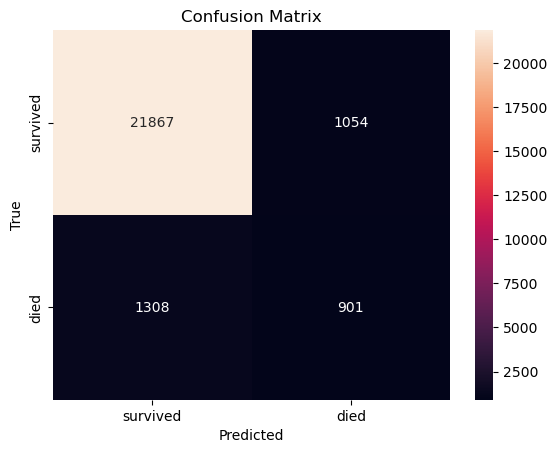

In [11]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.2f%%' % (accuracy * 100.0))
print('Recall: %.2f%%' % (recall * 100.0))
print('Precision: %.2f%%' % (precision * 100.0))
print('F1: %.2f%%' % (f1 * 100.0))

matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');
ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']);
ax.yaxis.set_ticklabels(['survived', 'died']);

In [12]:
matrix

array([[21867,  1054],
       [ 1308,   901]])

AUC: 0.8584421259638253


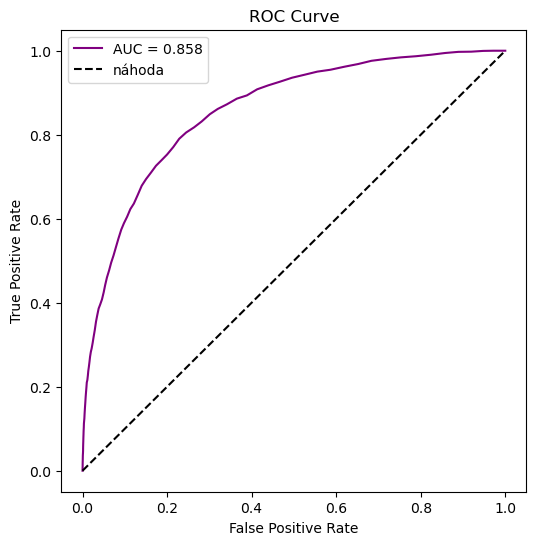

In [13]:
auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color = 'purple')
plt.plot([0,1], [0,1], 'k--', label='náhoda')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()